## Introduction to Linear Filters

Juan Diego Perez Navarro  
T00067699  
Universidad Tecnológica de Bolívar

In [2]:
from scipy import signal
from scipy import datasets
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
import skimage

## Brief Theory of Linear Filters

Tamaño Original:  (512, 512)


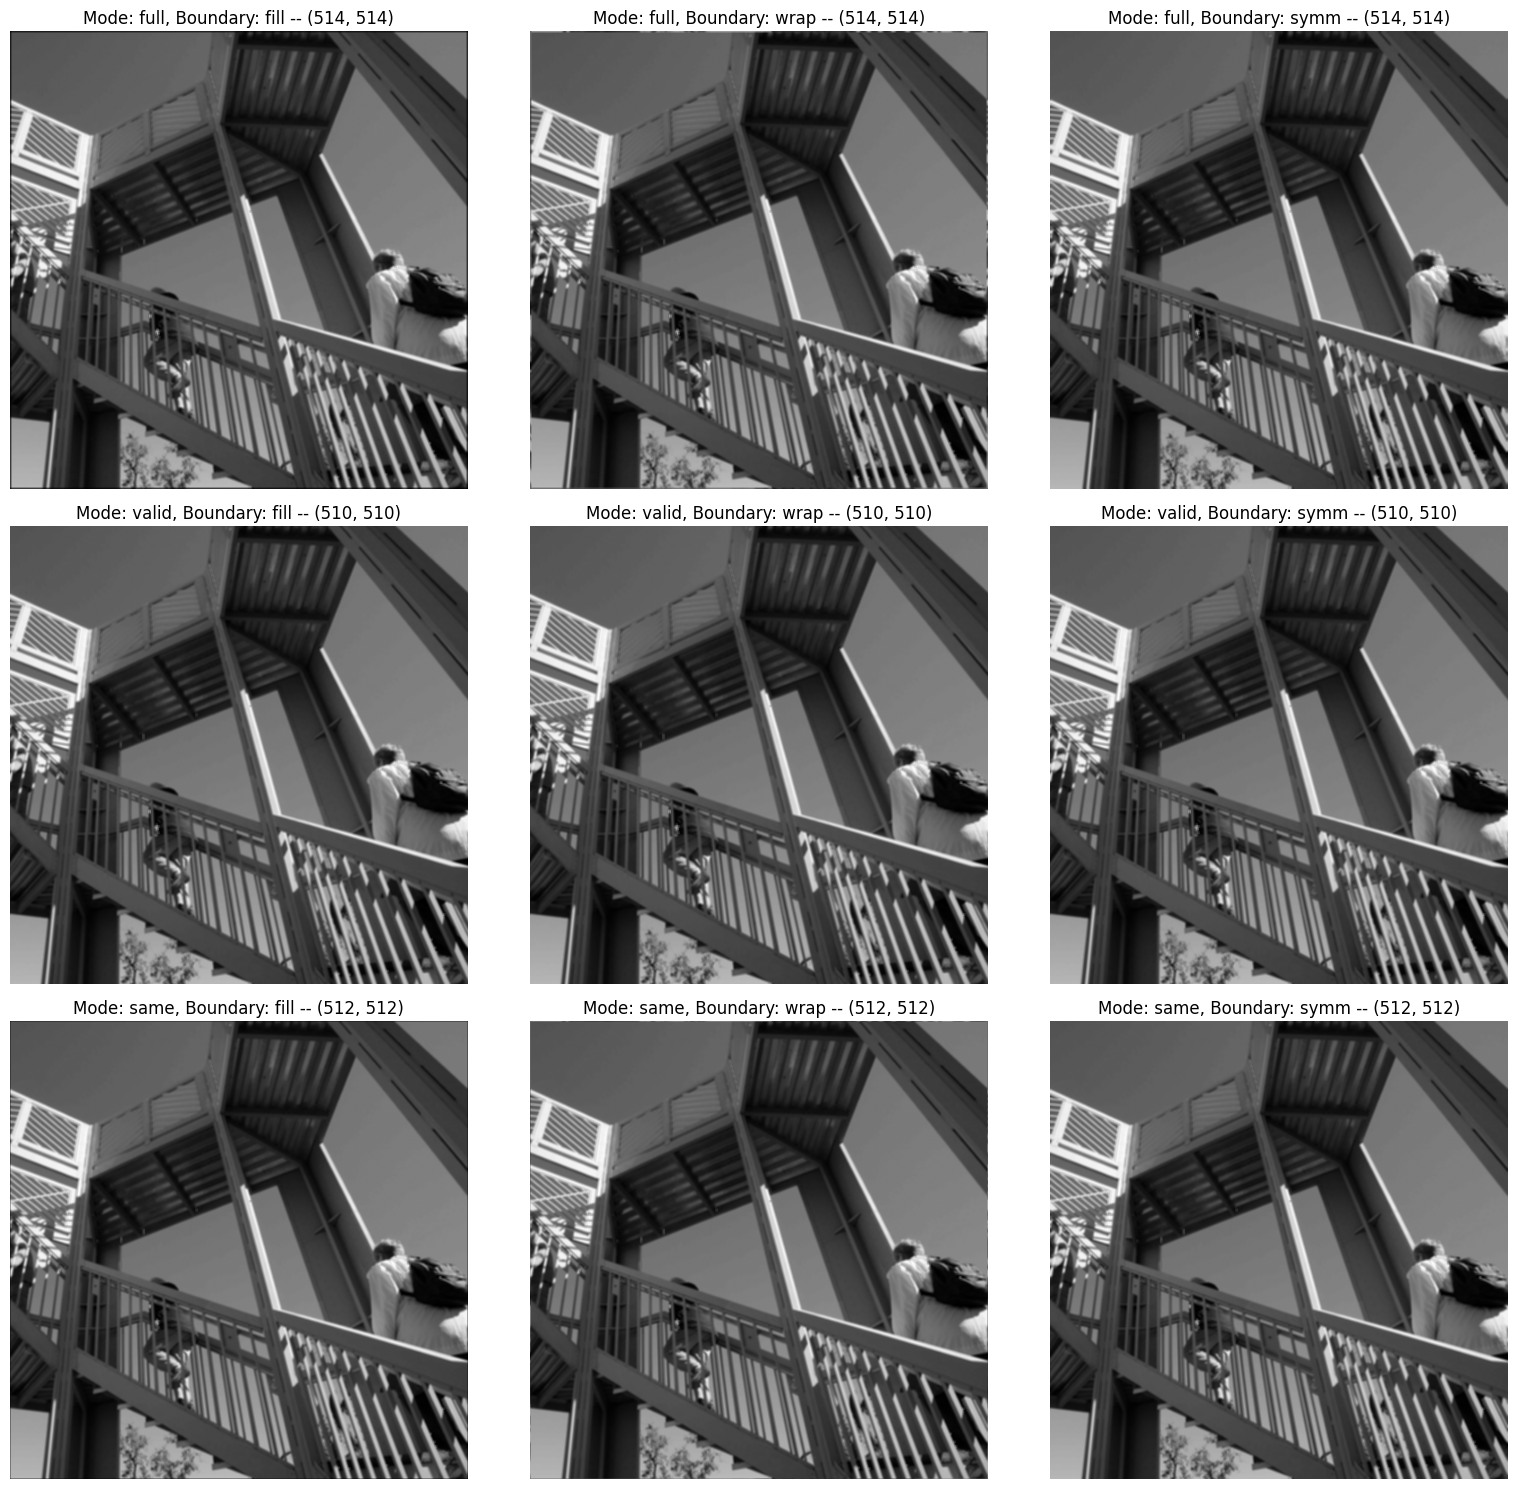

In [3]:
image = np.uint8(datasets.ascent())
print("Tamaño Original: ", image.shape)

box_fil = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]) * 1/9

sigma = 1
image_gaussian_filtered = gaussian_filter(image, sigma=sigma)

MODES = ["full", "valid", "same"]
BOUNDARIES = ["fill", "wrap", "symm"]

fig, axes = plt.subplots(3, 3, figsize=(16, 15))

for mode, row in zip(MODES, axes):
    for boundary, ax in zip(BOUNDARIES, row):
        image_filtered = signal.convolve2d(image, box_fil, boundary=boundary, mode=mode)
        ax.imshow(image_filtered, cmap="gray")
        ax.set_title(f"Mode: {mode}, Boundary: {boundary} -- {image_filtered.shape}")
        ax.axis("off")

fig.tight_layout()
plt.show()

Relacionado a lo que mencionó el profesor en clases, esto es lo que entiendo que hacen esos parametros:

Mode: Se refiere a cómo hacer la convolución.
* `full`. Realiza la convolución de tal manera que el filtro se interseque lo mínimo con la imagen original, lo que ocasiona que la imagen quede de tamaño mayor a la original.
* `valid`. Aquí la convolución se hace como originalmente se debería hacer, el kernel queda completamente dentro de la imagen, lo que provoca que el tamaño resultante sea menor a la original.
* `same`. Finalmente, con este modo lo que se hace es un punto medio de los anteriores. A la hora de hacer de convolución se hace de tal manera que el resultado sea del mismo tamaño de la imagen original.

Boundary: Cómo manejar los bordes
* `fill`. Los bordes que se toman de la convolución que no hacen parte de la imagen original se colocan como el parametro `fillvalue` se le especifique (por defecto, 0).
* `wrap` & `symm`. No termino de entender muy bien la diferencia entre ambos, pero sí se puede notar que con `wrap` queda un poco más feo en los bordes (al menos, a mi criterio), como si se trate de una especie de espejo. Con `symm` se ve más limpio.

Con `mode="valid"` no aplica ninguno de los boundary, pues aquí nunca se utilizan esos bordes que se agregan.

## Apllying a Median Filter to Remove Noise

[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


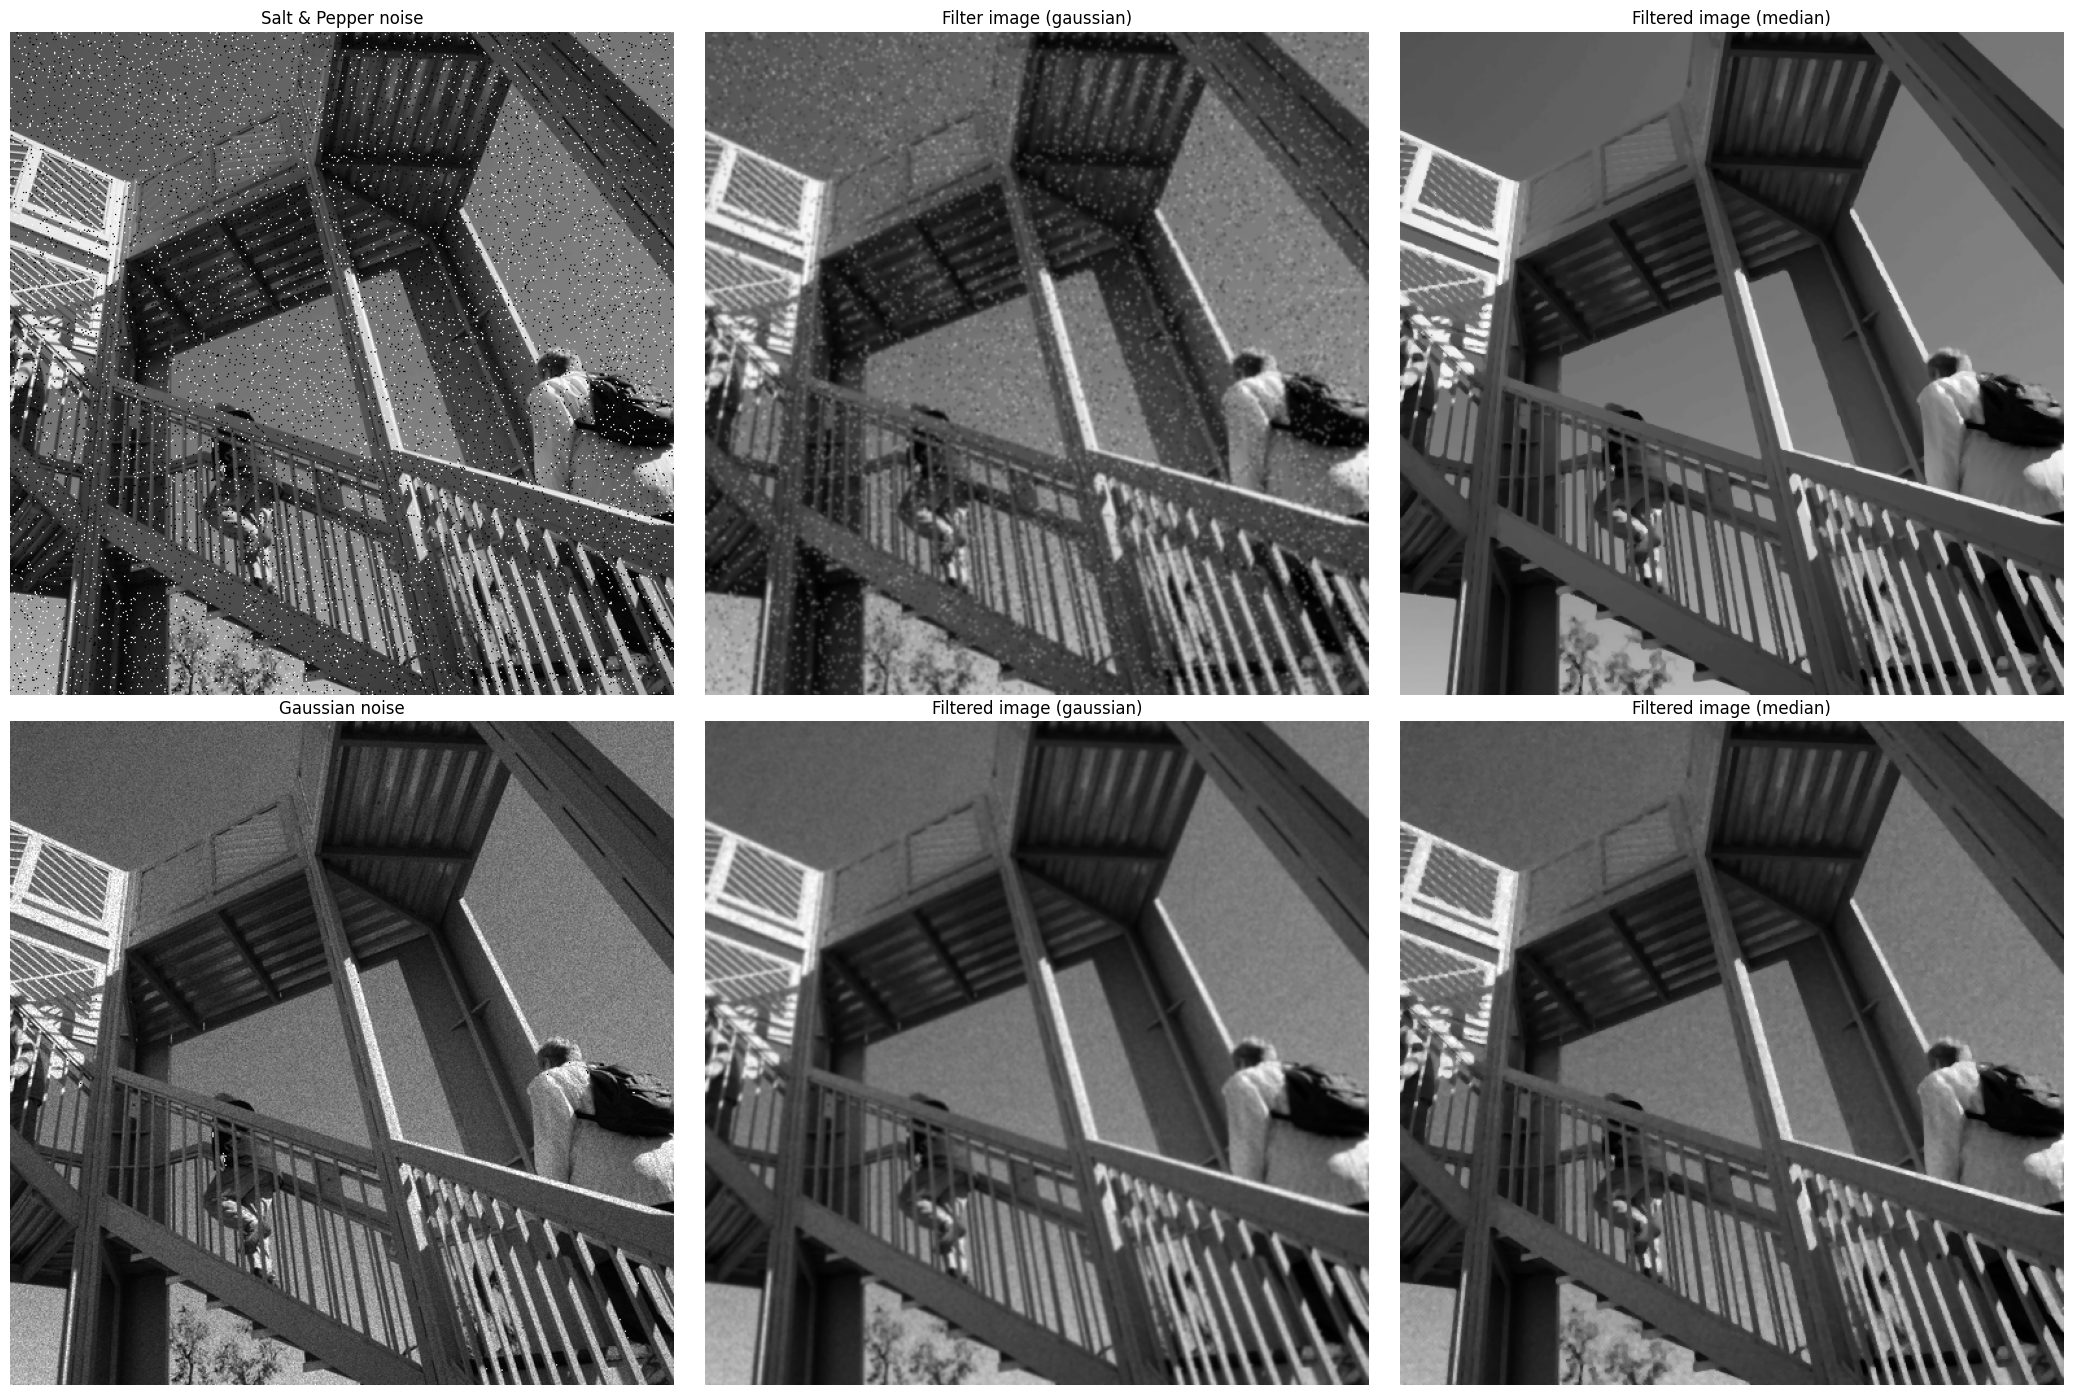

In [ ]:
from skimage.morphology import disk


print(disk(2))

image_noised = skimage.util.random_noise(image, mode="s&p")
gaussian = skimage.filters.gaussian(image_noised, sigma=1)
med = skimage.filters.median(image_noised, disk(2))

fig, axes = plt.subplots(2, 3, figsize=(21, 14))
axes[0, 0].imshow(image_noised, cmap='gray')
axes[0, 0].set_title('Salt & Pepper noise')
axes[0, 0].set_axis_off()

axes[0, 1].imshow(gaussian, cmap='gray')
axes[0, 1].set_title('Filter image (gaussian)')
axes[0, 1].set_axis_off()

axes[0, 2].imshow(med, cmap='gray')
axes[0, 2].set_title('Filtered image (median)')
axes[0, 2].set_axis_off()

image_noised = skimage.util.random_noise(image, mode="gaussian")
gaussian = skimage.filters.gaussian(image_noised, sigma=1)
med = skimage.filters.median(image_noised, disk(2))

axes[1, 0].imshow(image_noised, cmap='gray')
axes[1, 0].set_title('Gaussian noise')
axes[1, 0].set_axis_off()

axes[1, 1].imshow(gaussian, cmap='gray')
axes[1, 1].set_title('Filtered image (gaussian)')
axes[1, 1].set_axis_off()

axes[1, 2].imshow(med, cmap='gray')
axes[1, 2].set_title('Filtered image (median)')
axes[1, 2].set_axis_off()

fig.tight_layout()
plt.show()

## Let's Add Noise to the Image and Filter It

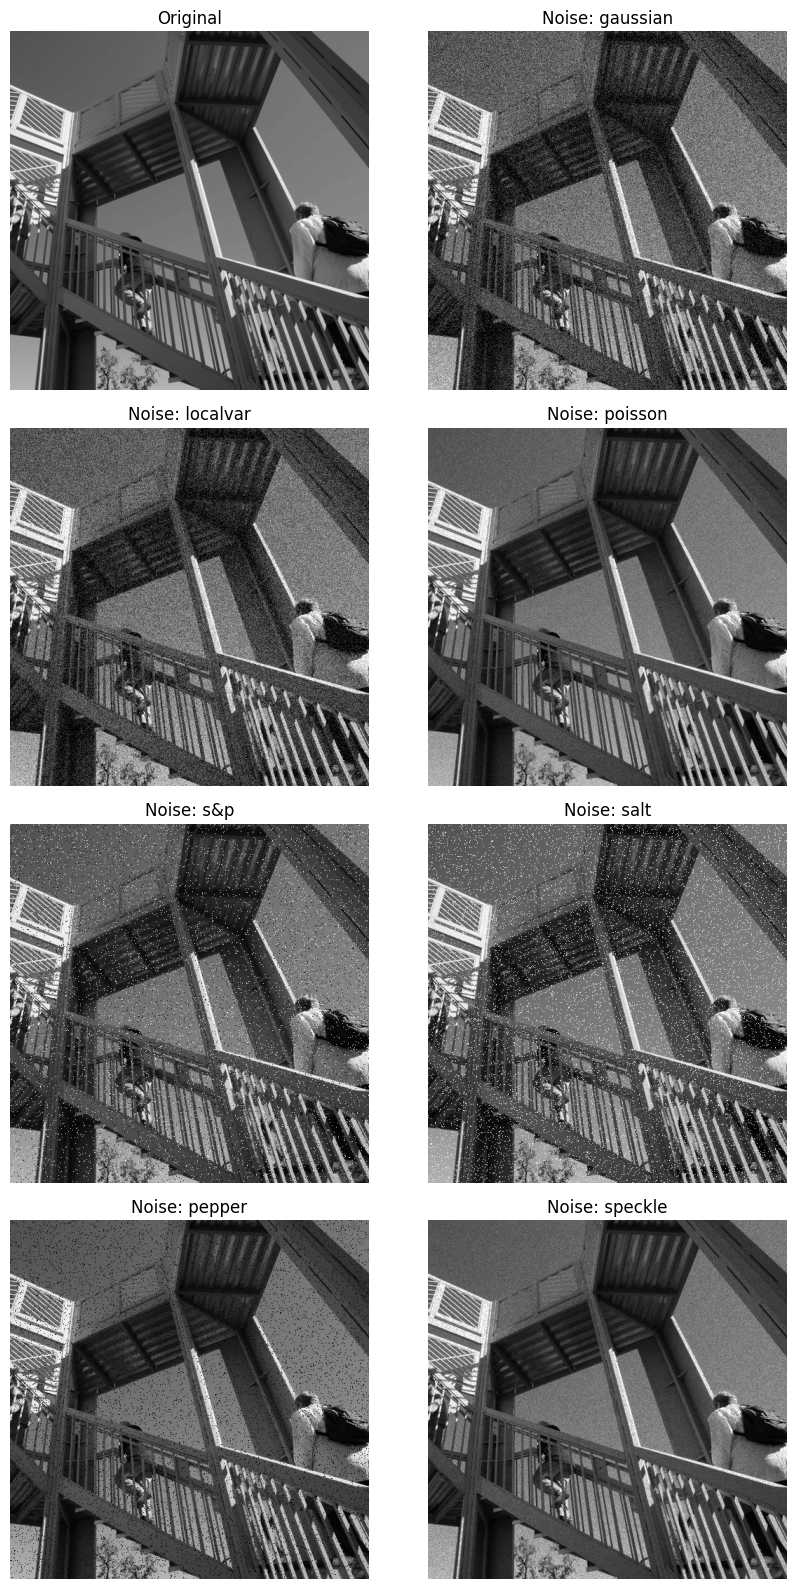

In [5]:
NOISE = ["gaussian", "localvar", "poisson", "s&p", "salt", "pepper", "speckle"]
fig, axes = plt.subplots(4, 2, figsize=(9, 16))

axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for noise, ax in zip(NOISE, axes.flatten()[1:]):
    image_noised = skimage.util.random_noise(image, mode=noise)
    ax.imshow(image_noised, cmap="gray")
    ax.set_title(f"Noise: {noise}")
    ax.axis("off")

fig.tight_layout()
plt.show()

## TODO: Further exploration

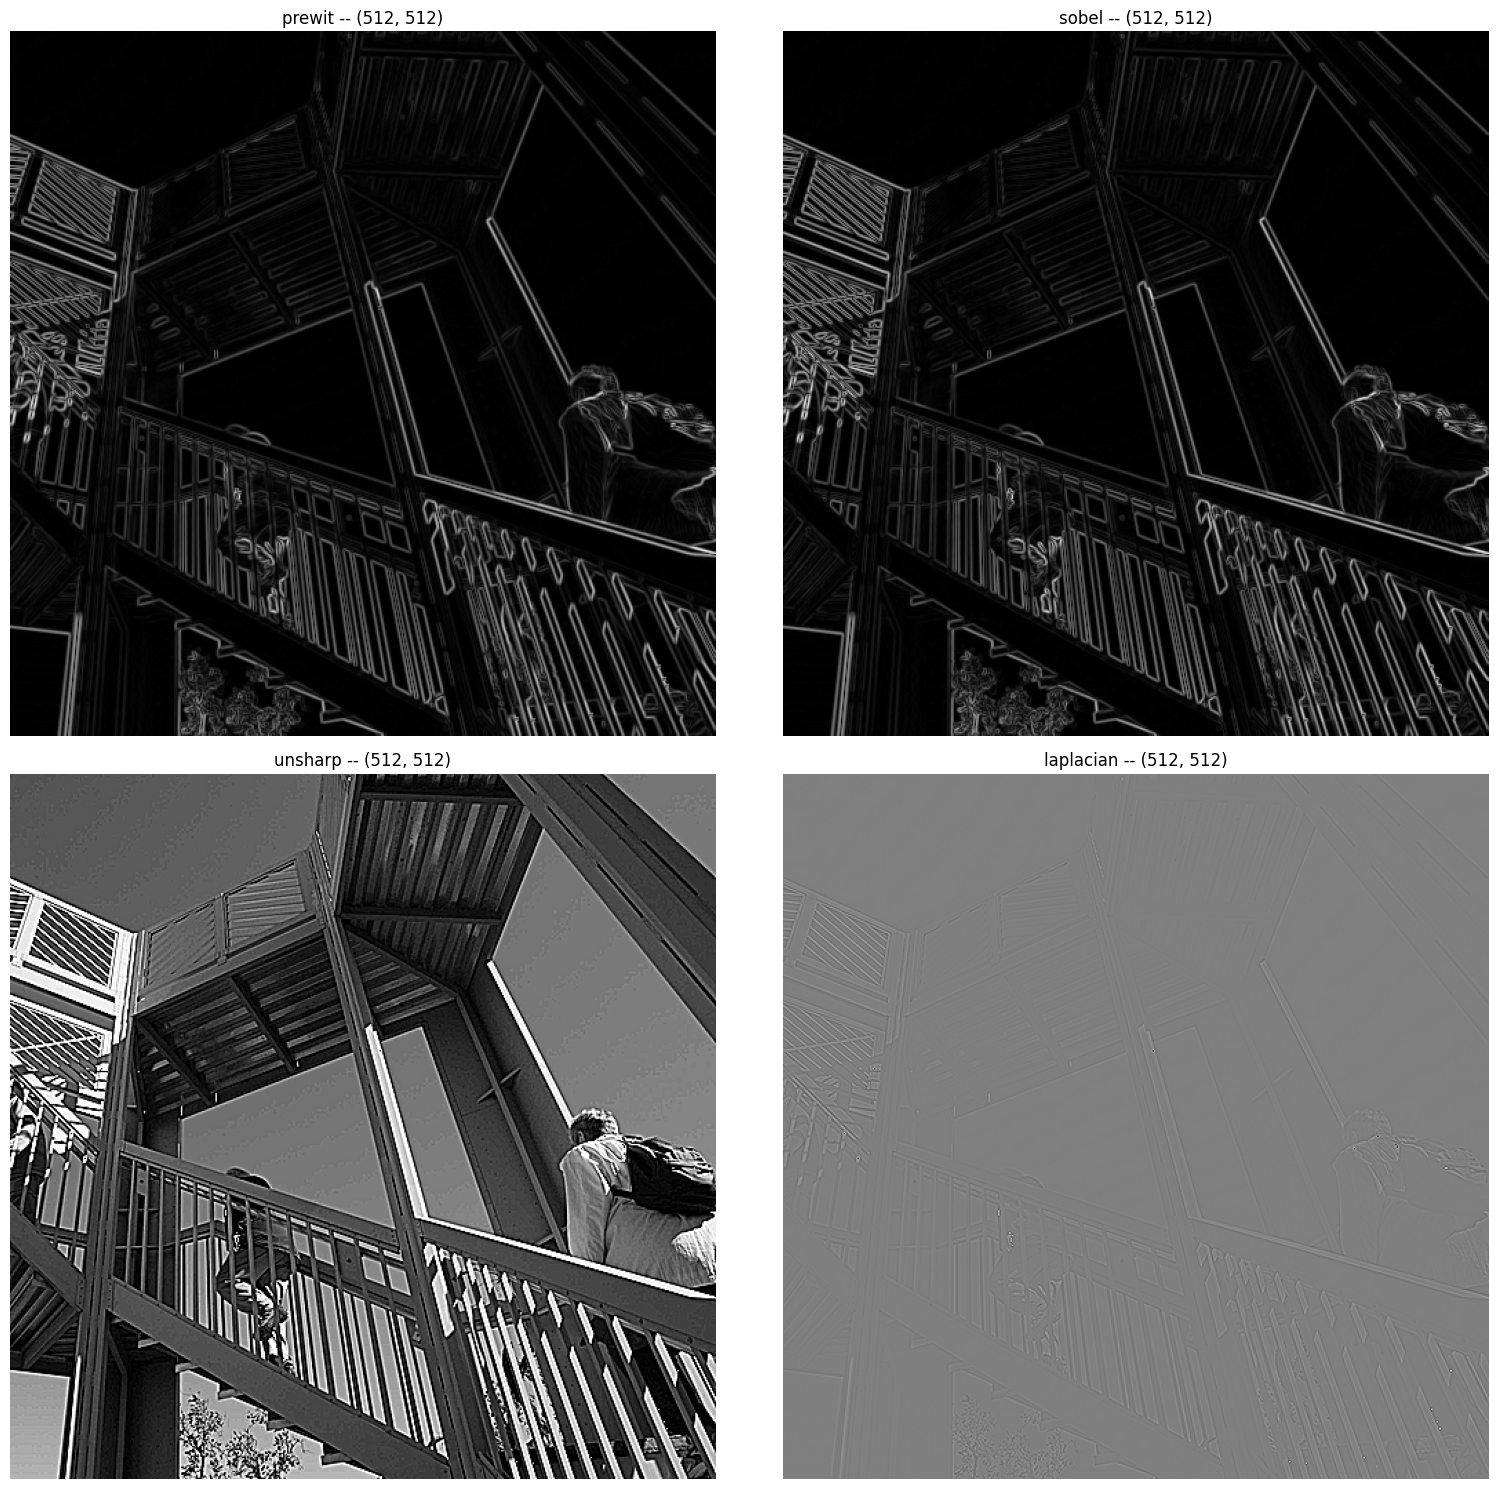

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 15))

filters = {
    "prewit": {"func": skimage.filters.prewitt, "kwargs": {"cval": 0.0}},
    "sobel": {"func": skimage.filters.sobel, "kwargs": {"cval": 0.0}},
    "unsharp": {"func": skimage.filters.unsharp_mask, "kwargs": {"radius": 1, "amount": 5}},
    "laplacian": {"func": skimage.filters.laplace, "kwargs": {"ksize": 3}}
}

for (name, filter), ax in zip(filters.items(), axes.flatten()):
    image_filtered = filter["func"](image, **filter["kwargs"])
    ax.imshow(image_filtered, cmap="gray")
    ax.set_title(f"{name} -- {image_filtered.shape}")
    ax.axis("off")

fig.tight_layout()
plt.show()

## TODO: Discussion and Conclusions

### 1. Understanding of linear filters

**1.1. Filtros pasa bajo.** Con los filtros pasa bajo lo que se busca es suprimir rangos altos de frecuencia. Resultando en imágenes suavizadas, de tal manera que se reduzca el ruido. Ejemplos: filtro de la mediana, filtro guasseano, etc.
**1.2. Filtros pasa alto.** Los filtros pasa alto son utilizados para detectar los cambios de luminosidad, los cuales se hacen útil a la hora de detectar bordes en la imagen. Por ejemplo, filtro de Sobel, Laplaciano, Prewitt, etc.
**1.3. Filtros pasa banda.** Los filtros pasa banda, al igual que los pasa bajo, son utilizados para eliminar el ruido. En el caso de la pasa banda, es útil para remover patrones de ruido.

**Fuentes:**
* [https://lapi.fi-p.unam.mx/wp-content/uploads/Practica-PDI-Filtros-Espaciales.pdf](https://lapi.fi-p.unam.mx/wp-content/uploads/Practica-PDI-Filtros-Espaciales.pdf).
* [https://www.lpi.tel.uva.es/~nacho/docencia/ing_ond_1/trabajos_03_04/sonificacion/cabroa_archivos/pasobajo.html](https://www.lpi.tel.uva.es/~nacho/docencia/ing_ond_1/trabajos_03_04/sonificacion/cabroa_archivos/pasobajo.html).
* [https://www.lpi.tel.uva.es/~nacho/docencia/ing_ond_1/trabajos_03_04/sonificacion/cabroa_archivos/pasoalto.html](https://www.lpi.tel.uva.es/~nacho/docencia/ing_ond_1/trabajos_03_04/sonificacion/cabroa_archivos/pasoalto.html).
* [https://grupo.us.es/gtocoma/pid/tema3-2.pdf](https://grupo.us.es/gtocoma/pid/tema3-2.pdf).

### 2. Non-Linear Filters

La diferencia principal que tienen los filtros lineales con los no lineales, según entiendo, tiene que ver con los principios de linealidad: $filter(A + B) = filter(A) + filter(B)$ y $filter(kA) = k filter(A)$. Según lo que he visto hasta el momento, todos los filtros lineales coinciden en ser "constantes", es decir, es un kernel fijo; en cambio, los filtros no lineales, están sujetas a la submatriz que se va escogiendo para hacer la convolución: filtro de la mediana. A mi parecer, esto consigue que sean filtros más personalizados.

Cuando se busca reducir el ruido sin afectar detalles importantes, los filtros no lineales, como el de mediana, suelen ser más efectivos que los filtros lineales, ya que preservan mejor los bordes y estructuras clave. En cambio, los filtros lineales son preferidos cuando se requiere un procesamiento más predecible y eficiente, como en la reducción de ruido gaussiano o en la detección de bordes mediante operadores diferenciales. Aunque los filtros lineales son más fáciles de analizar y aplicar mediante convoluciones, los no lineales permiten una mayor adaptación a las características locales de la imagen, lo que los hace más adecuados en escenarios donde la preservación de detalles es crucial.

### 3. Noise Reduction and Edge Detection

Depende mucho del tipo de ruido con el que se esté lidiando, pero me atrevería que, en general, los filtros de no lineales son mejores que los lineales. Esto porque, los filtros no lineales manejan mejor los datos atípicos que se presentan en los ruidos "salt", "pepper" y "s&p"; y en comparación a cómo se comportan con los ruidos que son como granulados (gausseano, speckle, etc.), tienen un comportamiento similar.

Para la detección de bordes, los filtros que se utilizaron en el notebook (prewitt, sobel y laplacian) son realmente muy buenos y se pueden combinar con otras técnicas a partir de ellos. Por ejemplo, para estos se podría realizar binarizaciones para realzar todavía más los bordes detectados. Y en el caso de "unsharp", mejora significamente la nítidez de la imagen.

### 4. Practical Considerations

Algunos de los filtros ofrecen la opción de separar el kernel por componentes en $x$ y $y$ (el caso de prewitt y sobel en skimage), provoca que la complejidad temporal sea menor. Ahora, todo este tema es más para tener en cuenta en imágenes de gran tamaño, al menos, en este laboratorio no fue un factor a considerar por el "pequeño" tamaño de la imagen, pero a futuro, con otras imagenes/señales es vital tenerlo en cuenta. Probablemente, las implementaciones de las funciones en Python estén lo máximo optimizado, pero sino, es vital tenerlo en cuenta.

### 5. Real-World Applications

En la práctica, para la detección de bordes lo primero que se debe hacer es un suavizado, o quitar el ruido de la imagen, para finalmente utilizar los filtros para detectar los bordes. ¿Para qué se podría implementar la detección de bordes? Un claro ejemplo podría ser el reconocimiento facial, en el cual se podría analizar los patrones para la detección de expresiones faciales.

> Holder, Ross & Tapamo, Jules-Raymond. (2017). Improved gradient local ternary patterns for facial expression recognition. EURASIP Journal on Image and Video Processing. 2017. 10.1186/s13640-017-0190-5.

### 6. Reflection on Challenges and Learning

Considero que el principal reto es entender la documentación de cada una de las funciones que existen y se utilizaron, preguntarse constantemente "¿qué hace este parámetro?". Y preguntarse eso es vital para luego poder utilizar correctamente estas funciones en fúturos proyectos, trabajos o tareas.

Todo el campo de visión artificial, relacionado con Machine Learning/Deep Learning, es algo que me apasiona bastante, y entender correctamente los pilares, como lo son los filtros en este caso, es clave para luego poder hacer proyectos en algún fúturo, no solo en la carrera, sino más en el campo laboral. Depende mucho del trabajo que se tenga, pero por ejemplo, en el caso de industrias alimenticia, puede ser útil un clasificador del estado del algún producto realizado automáticamente con visión artificial. O en el área de la salud, para detectar cancer por ejemplo.

> Monika Modzelewska-Kapituła, Soojin Jun, The application of computer vision systems in meat science and industry – A review, Meat Science, Volume 192, 2022, 108904, ISSN 0309-1740, https://doi.org/10.1016/j.meatsci.2022.108904.

> Asif Irshad Khan, Yoosef B. Abushark, Fawaz Alsolami, Abdulmohsen Almalawi, Md Mottahir Alam, Pravin Kshirsagar, Raees Ahmad Khan, Prediction of breast cancer based on computer vision and artificial intelligence techniques, Measurement, Volume 218, 2023, 113230, ISSN 0263-2241, https://doi.org/10.1016/j.measurement.2023.113230.

### 7. Suggestions for Further Exploration

Todo este tema de filtros es demasiado interesante, porque son demasiados que no se sabe hasta que punto qué se puede hacer y qué no. Pero, al final, lo único que se puede hacer en ese caso es seguir investigando, ya sea explorando la documentación de `skimage.filters` y probar uno a uno todos los filtros y comparar; o cada que tenga una idea espontanea preguntandome si existe un filtro que me sirva para X cosa, preguntarle a algún LLM para que me guíe en el tema y poder investigar.

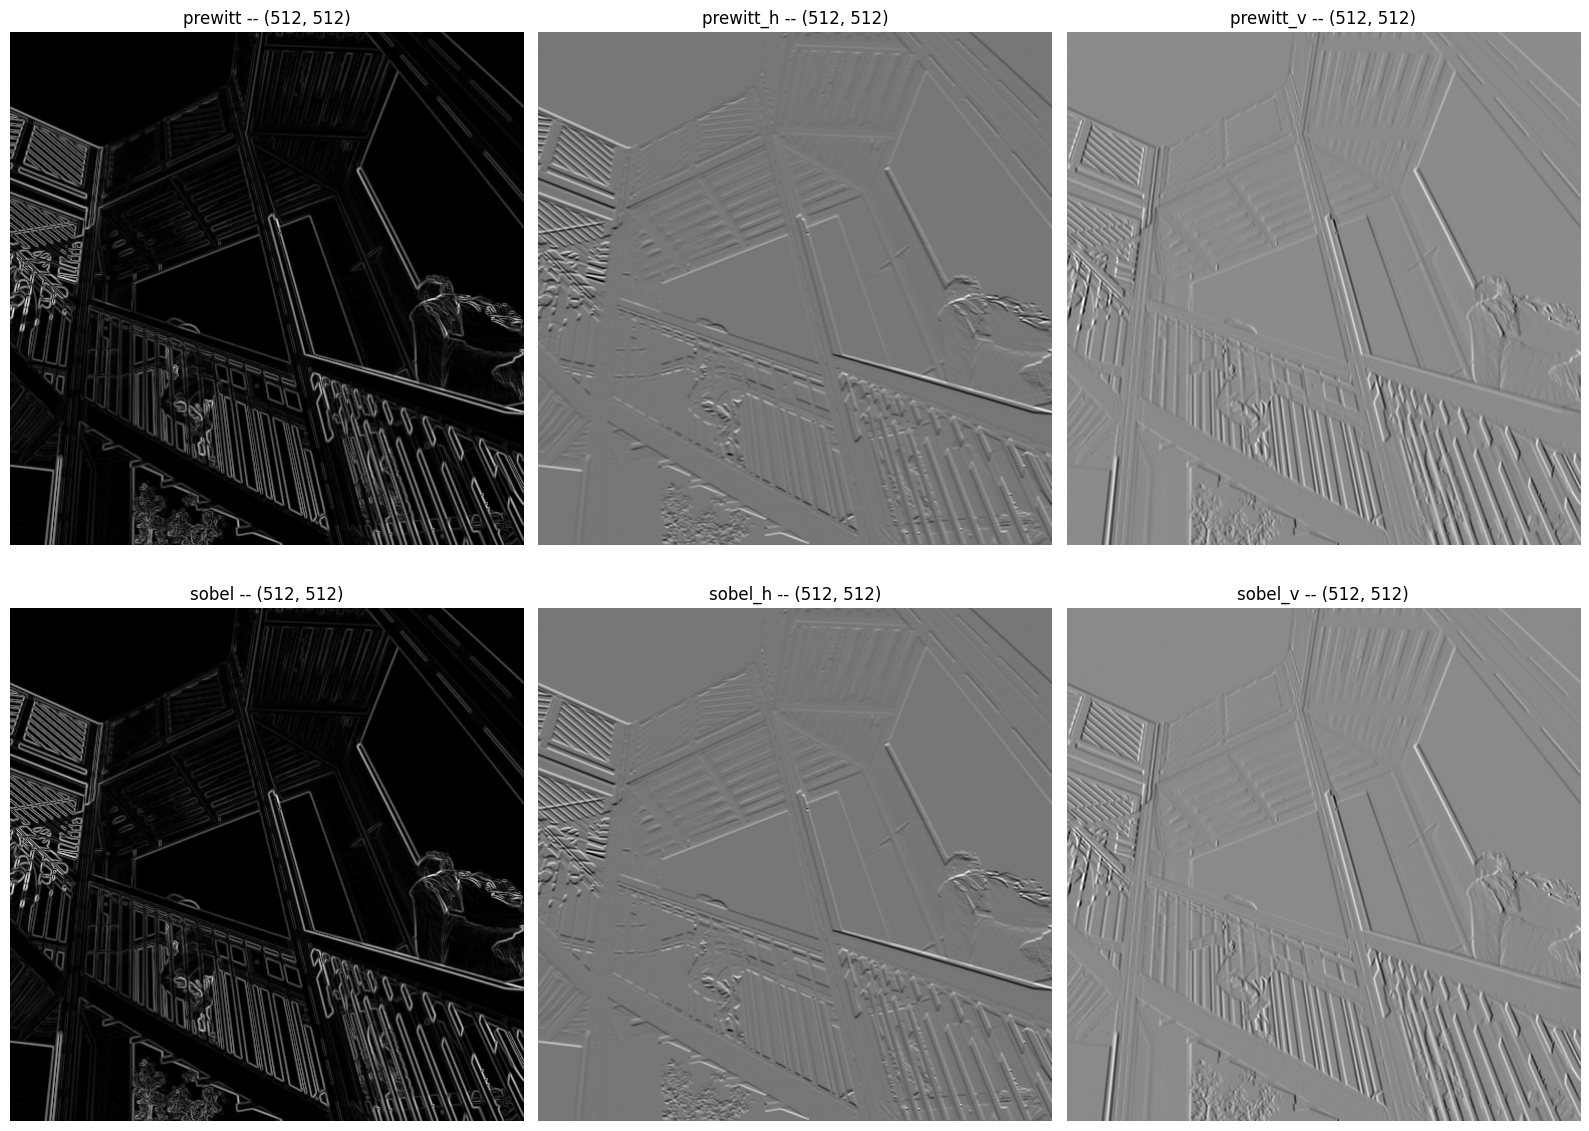

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

filters = {
    "prewitt": skimage.filters.prewitt,
    "prewitt_h": skimage.filters.prewitt_h,
    "prewitt_v": skimage.filters.prewitt_v,
    "sobel": skimage.filters.sobel,
    "sobel_h": skimage.filters.sobel_h,
    "sobel_v": skimage.filters.sobel_v
}

for (name, filter), ax in zip(filters.items(), axes.flatten()):
    image_filtered = filter(image)
    ax.imshow(image_filtered, cmap="gray")
    ax.set_title(f"{name} -- {image_filtered.shape}")
    ax.axis("off")

fig.tight_layout()
plt.show()

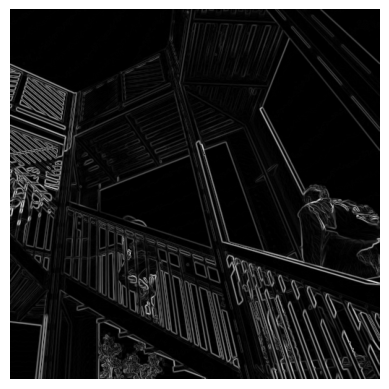

In [34]:
sobel_h_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_v_kernel = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

sobel_h = signal.convolve2d(image, sobel_h_kernel, mode="same", boundary="symm")
sobel_v = signal.convolve2d(image, sobel_v_kernel, mode="same", boundary="symm")
sobel = np.sqrt(sobel_h**2 + sobel_v**2)
plt.imshow(sobel, cmap="gray")
plt.axis("off")
plt.show()